In [15]:
from FFNN import FFNN
from AutoDiff import Value
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import check_random_state

In [16]:
t0 = time.time()
train_samples = 1000

In [17]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

In [18]:
random_state = check_random_state(0)
permutation = random_state.permutation(X.shape[0])
X = X[permutation]
y = y[permutation]
X = X.reshape((X.shape[0], -1))

In [19]:
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=train_samples, test_size=0.2
)

In [21]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
# Configure MLPClassifier
clf = MLPClassifier(
    hidden_layer_sizes=(20, ),  # One hidden layer with 100 neurons
    max_iter=10,  # Reduced for faster convergence
)

clf.fit(X_train, y_train)
score = clf.score(X_test, y_test)

print("Test score with MLPClassifier: %.4f" % score)

Test score with MLPClassifier: 0.7767


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


In [23]:
y_train

array(['5', '9', '5', '3', '0', '7', '9', '8', '4', '2', '6', '6', '2',
       '8', '1', '6', '4', '2', '0', '2', '4', '1', '9', '8', '8', '7',
       '2', '2', '4', '4', '9', '8', '3', '5', '9', '6', '3', '4', '1',
       '9', '6', '5', '6', '9', '9', '7', '7', '6', '4', '8', '4', '2',
       '8', '7', '0', '4', '9', '1', '6', '8', '7', '8', '3', '5', '9',
       '0', '4', '9', '6', '9', '4', '7', '2', '1', '7', '0', '3', '8',
       '5', '4', '4', '4', '0', '1', '1', '3', '3', '8', '5', '2', '1',
       '8', '5', '2', '5', '5', '2', '3', '4', '9', '8', '1', '3', '3',
       '0', '0', '2', '1', '3', '7', '4', '7', '9', '1', '4', '5', '0',
       '5', '9', '2', '2', '5', '1', '4', '7', '6', '5', '8', '2', '4',
       '9', '8', '6', '9', '9', '3', '0', '2', '4', '5', '3', '7', '6',
       '0', '1', '0', '1', '7', '7', '1', '2', '4', '8', '9', '9', '7',
       '2', '6', '1', '7', '5', '9', '0', '9', '9', '1', '0', '1', '6',
       '5', '0', '7', '4', '7', '9', '4', '2', '6', '9', '4', '3

In [24]:
model = FFNN(
    layers=[X_train.shape[1], 20, 10],
    activation_functions=["relu", "relu", "sigmoid"],
    loss_function="categorical_cross_entropy",
    random_state=42, learning_rate=0.1, epoch=10, verbose=1, 
    batch_size=1
)

model.weight_initializer(weight_initializer="normal", mean=0, variance=0.1)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
score = np.mean(y_pred == y_test)
print("Test score with MLPClassifier: %.4f" % score)

/Users/justin/Documents/ITB/Semester 6/Pembelajaran Mesin/Tugas Besar/Tubes 1/Tugas-Machine-Learning-1/src/FFNN.py:70: RuntimeWarning: overflow encountered in multiply
  gradient_input += neuron.weight * neuron.gradient_delta
/Users/justin/Documents/ITB/Semester 6/Pembelajaran Mesin/Tugas Besar/Tubes 1/Tugas-Machine-Learning-1/src/FFNN.py:52: RuntimeWarning: overflow encountered in multiply
  self.gradient_weight += self.gradient_delta * self.input


Epoch 1, Loss: nan
Epoch 2, Loss: nan
Epoch 3, Loss: nan
Epoch 4, Loss: nan
Epoch 5, Loss: nan
Epoch 6, Loss: nan
Epoch 7, Loss: nan
Epoch 8, Loss: nan
Epoch 9, Loss: nan
Epoch 10, Loss: nan
Test score with MLPClassifier: 0.0993


In [25]:
# model = FFNN(layers=[2, 16, 1], activation_functions=["relu", "linear"], loss_function="mse", batch_size=None, learning_rate=0.1, epoch=1000, verbose=1, random_state=10)
# model.weight_initializer(weight_initializer="normal", mean=0, variance=1, seed=10)
# model.fit(X, y)

Example run in 5.710 s


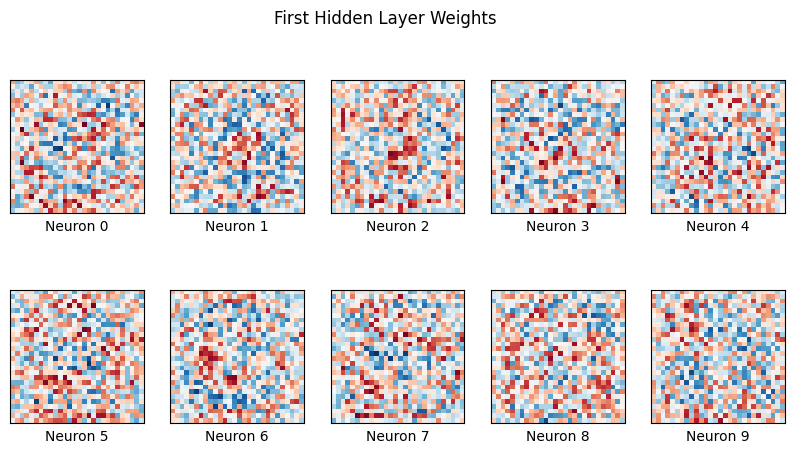

In [26]:
# Visualize weights of the first hidden layer
plt.figure(figsize=(10, 5))
weights = clf.coefs_[0]  # Weights of the first hidden layer
scale = np.abs(weights).max()
for i in range(10):
    l1_plot = plt.subplot(2, 5, i + 1)
    l1_plot.imshow(
        weights[:, i].reshape(28, 28),
        interpolation="nearest",
        cmap=plt.cm.RdBu,
        vmin=-scale,
        vmax=scale,
    )
    l1_plot.set_xticks(())
    l1_plot.set_yticks(())
    l1_plot.set_xlabel("Neuron %i" % i)

plt.suptitle("First Hidden Layer Weights")
run_time = time.time() - t0
print("Example run in %.3f s" % run_time)
plt.show()

In [27]:
run_time = time.time() - t0
print("Example run in %.3f s" % run_time)
plt.show()

Example run in 5.840 s


In [28]:
# model.visualize_graph()